# Single-Feature Clustering and Robustness Sweep — 7B (position-residualised)

**Purpose:**
1. Residualise all L1 features against `prompt_index` (removes execution-position confound).
2. Run a single-feature sweep over residualised features to identify the best discriminating feature.
3. Run a robustness sweep on that best residualised feature: for each subset size x, repeatedly
   draw x/2 emotional and x/2 neutral prompts per run, run k-means on the residualised feature,
   and record accuracy. Plot mean ± 1 SD vs x.

**Why residualise:**
Prompt index is assigned sequentially within a batch; any monotonic hardware trend (thermal
throttling, power state ramp-up) could confound condition differences. Residualising removes
the linear prompt-index effect before clustering.

## §1 — Imports and configuration

In [47]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'
RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
RUNS = ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3','4']

# ── L1 indicators ─────────────────────────────────────────────────────────────
L1_INDICATORS = [
    'hat_TLB',
    'tlb:tlb_flush',
    'core_power.throttle',
]

# ── Robustness sweep config ────────────────────────────────────────────────────
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20
N_INIT       = 50
RAND_SEED    = 42

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Repeats      : {N_REPEATS}')


Configuration OK
  Runs         : ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Subset sizes : [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
  Repeats      : 20


## §2 — Load data

In [48]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'independent{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')


Loaded 12 runs: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Total trials : 480
  Emotional    : 240
  Neutral      : 240


## §3 — Select L1 features

In [49]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[l1_cols].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]

print(f'L1 features available: {X_l1.shape[1]}')


L1 features available: 30


## §4 — Residualise all L1 features against `prompt_index`

For each feature, fit a simple linear regression on `prompt_index` and subtract the
fitted values. This removes any linear positional trend before clustering.

In [50]:
x_pos = df_all['prompt_index'].values.astype(float)

X_l1_resid = X_l1.copy()
for col in X_l1.columns:
    y_col = X_l1[col].values.astype(float)
    slope, intercept, _, _, _ = linregress(x_pos, y_col)
    X_l1_resid[col] = y_col - (slope * x_pos + intercept)

print('Residualised all L1 features against prompt_index.')
print(f'Features: {X_l1_resid.shape[1]}')
print(f'Residual means (should be ~0): min={X_l1_resid.mean().min():.4f}  max={X_l1_resid.mean().max():.4f}')


Residualised all L1 features against prompt_index.
Features: 30
Residual means (should be ~0): min=-0.0002  max=0.0000


## §5 — Single-feature sweep on residualised features

In [57]:
def kmeans_acc_ari(X, y, n_init=50, seed=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


y_true = df_all['label'].values
runs_unique = df_all['run'].unique()

records_resid = []
for col in X_l1_resid.columns:
    acc, ari = kmeans_acc_ari(X_l1_resid[[col]].values, y_true,
                              n_init=N_INIT, seed=RAND_SEED)
    e_mean = X_l1_resid.loc[df_all['condition'] == 'emotional', col].mean()
    n_mean = X_l1_resid.loc[df_all['condition'] == 'neutral',   col].mean()
    direction = '↑E' if e_mean > n_mean else '↑N'

    # Per-run direction: count how many runs agree with the majority direction
    run_dirs = []
    for run in runs_unique:
        mask_run = df_all['run'] == run
        e_run = X_l1_resid.loc[mask_run & (df_all['condition'] == 'emotional'), col].mean()
        n_run = X_l1_resid.loc[mask_run & (df_all['condition'] == 'neutral'),   col].mean()
        if not (np.isnan(e_run) or np.isnan(n_run)):
            run_dirs.append('↑E' if e_run > n_run else '↑N')
    majority_dir    = max(set(run_dirs), key=run_dirs.count) if run_dirs else '?'
    n_runs_majority = sum(1 for d in run_dirs if d == majority_dir)

    records_resid.append({
        'feature':       col,
        'indicator':     indicator_of(col),
        'metric':        col.split('__')[-1],
        'accuracy':      acc,
        'ari':           ari,
        'direction':     direction,
        'runs_majority': f'{n_runs_majority}/{len(run_dirs)}',
    })

sf_resid = pd.DataFrame(records_resid).sort_values('accuracy', ascending=False).reset_index(drop=True)

BEST_FEATURE = sf_resid.iloc[1]['feature']
BEST_ACC     = sf_resid.iloc[1]['accuracy']
BEST_ARI     = sf_resid.iloc[1]['ari']

print(f'Best single feature (residualised): {BEST_FEATURE}')
print(f'  Accuracy       : {BEST_ACC:.4f}')
print(f'  ARI            : {BEST_ARI:.4f}')
print(f'  Direction      : {sf_resid.iloc[0]["direction"]}')
print()
print('Top 10:')
print(sf_resid[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))


Best single feature (residualised): core_power.throttle__spectral_entropy
  Accuracy       : 0.5417
  ARI            : 0.0049
  Direction      : ↑N

Top 10:
                              feature  accuracy       ari direction runs_majority
       core_power.throttle__mean_rate  0.547917  0.007130        ↑N         11/12
core_power.throttle__spectral_entropy  0.541667  0.004881        ↑E          7/12
                  hat_TLB__burst_rate  0.529167  0.001332        ↑N          7/12
      tlb:tlb_flush__burst_clustering  0.529167  0.001424        ↑N          7/12
      core_power.throttle__burst_rate  0.529167  0.001323        ↑N         11/12
           core_power.throttle__slope  0.529167  0.001599        ↑N         11/12
         core_power.throttle__p90_p10  0.527083  0.001086        ↑N         10/12
core_power.throttle__burst_clustering  0.525000  0.000544        ↑N          8/12
            tlb:tlb_flush__burst_rate  0.522917  0.001658        ↑E          7/12
                tlb:tlb

## §6 — Robustness sweep on the best residualised feature

For each subset size x and each of the 20 repeats:
- Draw x/2 emotional and x/2 neutral **prompt indices** uniformly at random.
- Select all trials matching those prompt indices.
- Residualise the feature against prompt_index **within the subset** (same linear fit
  applied to the subset to stay self-contained).
- Run k-means and record accuracy and ARI.

In [52]:
emotional_prompts = sorted(df_all[df_all.condition == 'emotional']['prompt_index'].unique())
neutral_prompts   = sorted(df_all[df_all.condition == 'neutral']['prompt_index'].unique())

print(f'Emotional prompt indices ({len(emotional_prompts)}): {emotional_prompts}')
print(f'Neutral prompt indices   ({len(neutral_prompts)}):   {neutral_prompts}')


Emotional prompt indices (20): [np.int64(0), np.int64(1), np.int64(2), np.int64(7), np.int64(8), np.int64(13), np.int64(14), np.int64(18), np.int64(24), np.int64(25), np.int64(28), np.int64(29), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39)]
Neutral prompt indices   (20):   [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(27), np.int64(30), np.int64(31)]


In [53]:
rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        sub = df_all[mask].copy()

        # Residualise the best feature within this subset
        x_sub_pos = sub['prompt_index'].values.astype(float)
        y_sub_feat = sub[BEST_FEATURE].fillna(sub[BEST_FEATURE].median()).values.astype(float)
        slope_s, intercept_s, _, _, _ = linregress(x_sub_pos, y_sub_feat)
        X_sub_resid = (y_sub_feat - (slope_s * x_sub_pos + intercept_s)).reshape(-1, 1)

        y_sub = sub['label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub_resid, y_sub, n_init=N_INIT, seed=RAND_SEED)
        accs.append(acc)
        aris.append(ari)

    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)


  x=22  total= 264  mean_acc=0.5439  ±0.0188  mean_ARI=0.0054
  x=24  total= 288  mean_acc=0.5469  ±0.0151  mean_ARI=0.0063
  x=26  total= 312  mean_acc=0.5481  ±0.0191  mean_ARI=0.0075
  x=28  total= 336  mean_acc=0.5467  ±0.0169  mean_ARI=0.0069
  x=30  total= 360  mean_acc=0.5382  ±0.0132  mean_ARI=0.0038
  x=32  total= 384  mean_acc=0.5451  ±0.0098  mean_ARI=0.0059
  x=34  total= 408  mean_acc=0.5425  ±0.0084  mean_ARI=0.0051
  x=36  total= 432  mean_acc=0.5464  ±0.0093  mean_ARI=0.0067
  x=38  total= 456  mean_acc=0.5431  ±0.0038  mean_ARI=0.0053
  x=40  total= 480  mean_acc=0.5417  ±0.0000  mean_ARI=0.0049


## §7 — Plot

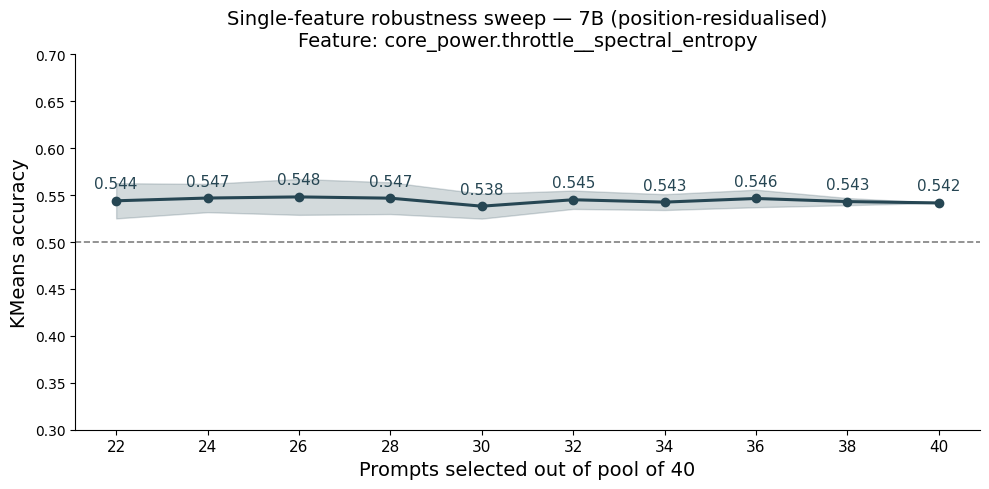

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/single_feature_robustness_7b_residualised.png


In [54]:
COLOR = '#264653'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(xs, mean, marker='o', lw=2.2, color=COLOR, zorder=3,
        label=f'Best residualised feature: {BEST_FEATURE}')
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.20, color=COLOR, label='± 1 SD across 20 repeats')

for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', (xi, mi),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=11, color=COLOR)

ax.axhline(0.5, color='grey', lw=1.2, ls='--', label='Chance (0.50)')

ax.set_xlabel('Prompts selected out of pool of 40', fontsize=14)
ax.set_ylabel('KMeans accuracy', fontsize=14)
ax.set_title(
    f'Single-feature robustness sweep — 7B (position-residualised)\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=14
)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=11)
ax.set_ylim(0.3, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = RESULT_DIR / 'single_feature_robustness_7b_residualised.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## §8 — Summary table

In [55]:
print('Single-feature robustness sweep — 70B (position-residualised)')
print(f'Best feature: {BEST_FEATURE}')
print(f'Full-dataset accuracy (x=40): {res[res.x==40].mean_acc.values[0]:.4f}')
print()
print(f'  {"x":>4}  {"total":>6}  {"mean acc":>9}  {"± SD":>7}  {"mean ARI":>9}  {"± SD":>7}')
print('-' * 60)
for _, r in res.iterrows():
    print(f'  {int(r.x):>4}  {int(r.total):>6}  {r.mean_acc:>9.4f}  '
          f'{r.std_acc:>7.4f}  {r.mean_ari:>9.4f}  {r.std_ari:>7.4f}')
print()
print('Chance baseline: 0.5000')


Single-feature robustness sweep — 70B (position-residualised)
Best feature: core_power.throttle__spectral_entropy
Full-dataset accuracy (x=40): 0.5417

     x   total   mean acc     ± SD   mean ARI     ± SD
------------------------------------------------------------
    22     264     0.5439   0.0188     0.0054   0.0067
    24     288     0.5469   0.0151     0.0063   0.0053
    26     312     0.5481   0.0191     0.0075   0.0071
    28     336     0.5467   0.0169     0.0069   0.0070
    30     360     0.5382   0.0132     0.0038   0.0044
    32     384     0.5451   0.0098     0.0059   0.0035
    34     408     0.5425   0.0084     0.0051   0.0031
    36     432     0.5464   0.0093     0.0067   0.0031
    38     456     0.5431   0.0038     0.0053   0.0013
    40     480     0.5417   0.0000     0.0049   0.0000

Chance baseline: 0.5000


## §9 — Distribution of residuals per condition

emotional   n= 240  mean=0.0050  median=0.0060  std=0.0843
neutral     n= 240  mean=-0.0050  median=-0.0147  std=0.0858


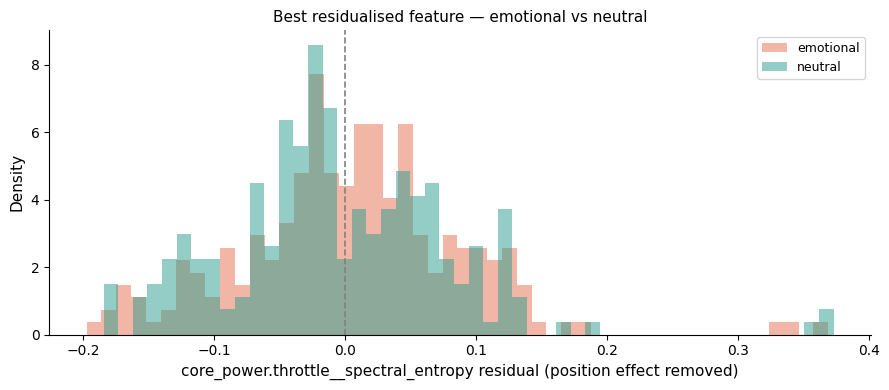

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/single_feature_residual_distribution_7b.png


In [56]:
for cond in ['emotional', 'neutral']:
    vals = X_l1_resid.loc[df_all['condition'] == cond, BEST_FEATURE]
    print(f'{cond:10s}  n={len(vals):4d}  mean={vals.mean():.4f}  '
          f'median={vals.median():.4f}  std={vals.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
    vals = X_l1_resid.loc[df_all['condition'] == cond, BEST_FEATURE]
    ax.hist(vals, bins=50, alpha=0.5, color=color, label=cond, density=True)
ax.axvline(0, color='grey', lw=1.2, ls='--')
ax.set_xlabel(f'{BEST_FEATURE} residual (position effect removed)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Best residualised feature — emotional vs neutral', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
out = RESULT_DIR / 'single_feature_residual_distribution_7b.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')
